In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from nolitsa import dimension

In [2]:
# Cargar datos de temperatura
ruta_datos = r"../data/interim/temperatura_regional_horaria.parquet"
df = pd.read_parquet(
    ruta_datos, 
    engine="pyarrow"
    )
df = df.sort_values(by=["region", "fecha_hora"])
regiones = df["region"].unique().tolist()

In [7]:
# Parámetros de FNN
tau = 1       # Retardo (Time delay) de 1 hora.
max_dim = 15    # Probaremos desde 1 hasta 15 dimensiones (hasta t-15 horas).
dim_array = np.arange(1, max_dim + 1)  # arreglo de dimensiones de análisis
R = 30.0  # dimensión de toleranacia para el FNN Test tipo I

grouped = df.groupby("region")

fnn_reg = {}

for region in regiones: 
    print(f"\nRegión: {region}")
    print(f"Calculando FNN hasta la dimensión {max_dim}. Esto puede tomar unos segundos...")
    
    # Extraemos el sub-dataframe exclusivo de esta comuna usando el grupo
    df_region = grouped.get_group(region)
    
    # Limpiamos nulos únicamente en la columna de temperatura y extraemos el array de numpy
    # (Asegúrate de que la columna se llame exactamente "temperatura" en tu archivo)
    temp_series = df_region["temperatura"].dropna().values.astype(np.float64)
    
    # Validar que tengamos suficientes datos para el análisis
    if len(temp_series) < max_dim * tau:
        print(f"Advertencia: {region} no tiene suficientes datos. Saltando...")
        continue
        
    # Calcular las fracciones de falsos vecinos
    fnn_fractions = dimension.fnn(temp_series, tau=tau, dim=dim_array)
    
    # Guardamos los resultados (fnn_fractions suele entregar una matriz, extraemos la primera fila)
    fnn_reg[region] = fnn_fractions[0, :]

# Crear el DataFrame con los resultados del test
df_fnn = pd.DataFrame(fnn_reg, index=dim_array)
print("\n¡Análisis FNN completado para las comunas de prueba!")
print(df_fnn.head())


Región: ANTOFAGASTA
Calculando FNN hasta la dimensión 15. Esto puede tomar unos segundos...

Región: ARICA Y PARINACOTA
Calculando FNN hasta la dimensión 15. Esto puede tomar unos segundos...

Región: ATACAMA
Calculando FNN hasta la dimensión 15. Esto puede tomar unos segundos...

Región: AYSÉN DEL GENERAL CARLOS IBÁÑEZ DEL CAMPO
Calculando FNN hasta la dimensión 15. Esto puede tomar unos segundos...

Región: BIOBÍO
Calculando FNN hasta la dimensión 15. Esto puede tomar unos segundos...

Región: COQUIMBO
Calculando FNN hasta la dimensión 15. Esto puede tomar unos segundos...

Región: LA ARAUCANÍA
Calculando FNN hasta la dimensión 15. Esto puede tomar unos segundos...

Región: LIBERTADOR GENERAL BERNARDO O'HIGGINS
Calculando FNN hasta la dimensión 15. Esto puede tomar unos segundos...

Región: LOS LAGOS
Calculando FNN hasta la dimensión 15. Esto puede tomar unos segundos...

Región: LOS RÍOS
Calculando FNN hasta la dimensión 15. Esto puede tomar unos segundos...

Región: MAGALLANES Y D

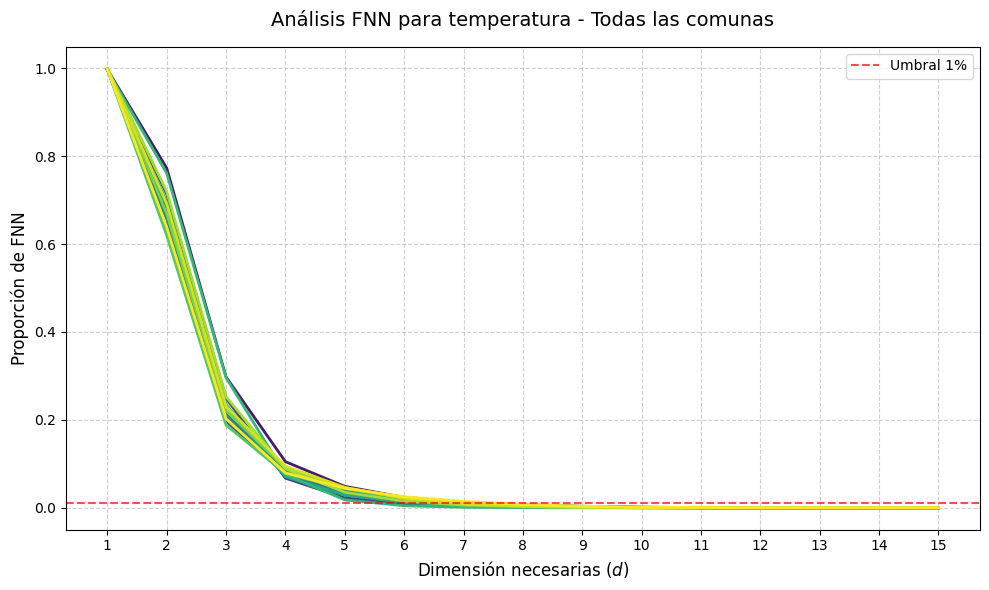

In [8]:
# graficar resultados
plt.figure(figsize=(10, 6))
comunas_actual = df_fnn.columns.to_list()
cmap = plt.get_cmap("viridis", len(comunas_actual))
for i, reg in enumerate(comunas_actual):
    plt.plot(dim_array, df_fnn[reg], linestyle='-', color=cmap(i), linewidth=2)
plt.axhline(y=0.01, color='red', linestyle='--', alpha=0.7, label='Umbral 1%')

# Formato del gráfico
plt.title('Análisis FNN para temperatura - Todas las comunas', fontsize=14, pad=15)
plt.xlabel('Dimensión necesarias ($d$)', fontsize=12)
plt.ylabel('Proporción de FNN', fontsize=12)
plt.xticks(dim_array)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()

plt.show()

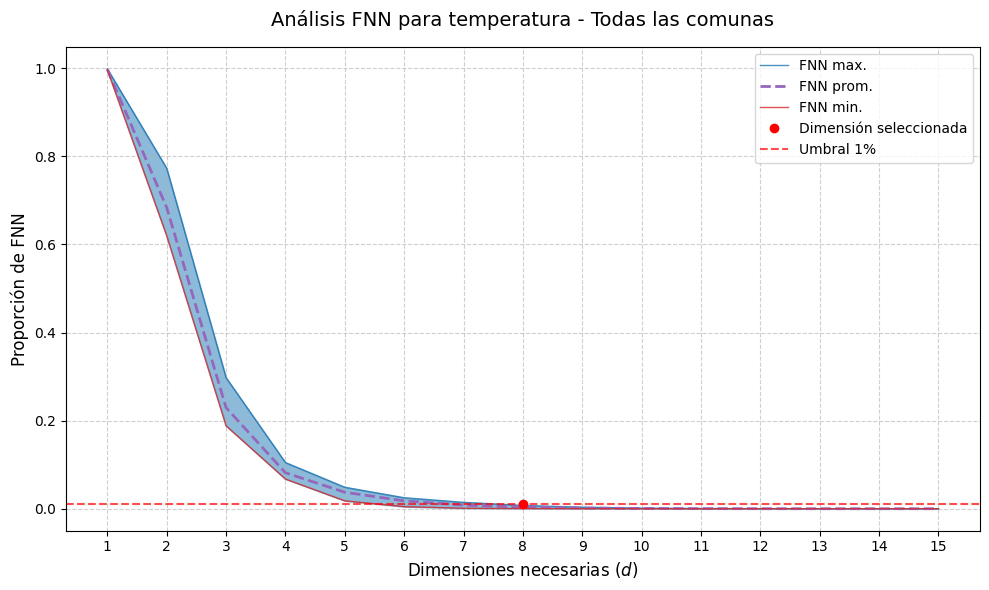

In [9]:
# graficar resultados
plt.figure(figsize=(10, 6))
comunas_actual = df_fnn.columns.to_list()
plt.plot(dim_array, df_fnn.max(axis=1), linestyle='-', color="tab:blue", linewidth=1, alpha=0.8, label="FNN max.")
plt.plot(dim_array, df_fnn.mean(axis=1), linestyle='--', color="tab:purple", linewidth=2, label="FNN prom.")
plt.plot(dim_array, df_fnn.min(axis=1), linestyle='-', color="tab:red", linewidth=1, alpha=0.8, label="FNN min.")
plt.fill_between(dim_array, y1=df_fnn.max(axis=1), y2=df_fnn.min(axis=1), color="tab:blue", alpha=0.5)
plt.plot(dim_array[7], 0.01, "o", color="red", label="Dimensión seleccionada")
plt.axhline(y=0.01, color='red', linestyle='--', alpha=0.7, label='Umbral 1%')

# Formato del gráfico
plt.title('Análisis FNN para temperatura - Todas las comunas', fontsize=14, pad=15)
plt.xlabel('Dimensiones necesarias ($d$)', fontsize=12)
plt.ylabel('Proporción de FNN', fontsize=12)
plt.xticks(dim_array)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.savefig("../data/interim/FNN_temperaturas.png", transparent=True, dpi=600)
plt.show()